# 09 — Interpreting BaseAttentive: Attention Patterns & Feature Importance

> **Goal**: Go beyond accuracy numbers — extract and visualise *every* internal
> attention signal the model produces to understand *why* it makes each prediction.

## Scenario — Smart Building Energy Demand Forecasting

| Modality | Features | Known importance |
|----------|----------|-----------------|
| **Static** | `floor_area`, `building_age`, `insulation`, `bldg_type` | HIGH / LOW / LOW / MOD |
| **Dynamic** | `temperature`, `occupancy`, `humidity`, `wind_speed`, `cloud_cover`, `price_signal` | HIGH / HIGH / MOD / LOW / LOW / LOW |
| **Future** | `hour_sin`, `hour_cos`, `forecast_temp` | HIGH / HIGH / HIGH |
| **Target** | Hourly energy demand for the next 24 h | — |

Because the target is a **known function** of these inputs, we can verify whether
the model's explanations agree with ground truth.

## Interpretability Toolkit

| # | Technique | What it reveals |
|---|-----------|----------------|
| 1 | Variable Selection Networks (VSN) | Per-feature softmax importance weights |
| 2 | Cross-attention heatmaps | Decoder queries × encoder key positions |
| 3 | Hierarchical self-attention | Intra-horizon temporal structure |
| 4 | Multi-head diversity | Specialisation across 4 attention heads |
| 5 | Gradient-based saliency | Which past time steps drive the output |
| 6 | Horizon-dependent attention | How focus shifts across the 24-step horizon |
| 7 | Contrastive analysis | Peak vs off-peak demand attention differences |
| 8 | Integrated gradients | Attribution with zero-baseline comparison |

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('BASE_ATTENTIVE_BACKEND', 'tensorflow')
os.environ.setdefault('KERAS_BACKEND',          'tensorflow')

import keras           # must import before base_attentive for Keras 3 backend init
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

import base_attentive
from base_attentive import BaseAttentive

# ── Global constants ───────────────────────────────────────────────────────────
LOOKBACK   = 48   # hours of past data
HORIZON    = 24   # hours to forecast
N_STATIC   = 4
N_DYNAMIC  = 6
N_FUTURE   = 3
OUTPUT_DIM = 1
EMBED_DIM  = 48
N_HEADS    = 4
EPOCHS     = 40
BATCH_SIZE = 32
N_SAMPLES  = 256
EXT_BATCH  = 32   # samples used for attention extraction

STATIC_NAMES  = ['floor_area', 'building_age', 'insulation', 'bldg_type']
DYNAMIC_NAMES = ['temperature', 'occupancy', 'humidity',
                 'wind_speed', 'cloud_cover', 'price_signal']
FUTURE_NAMES  = ['hour_sin', 'hour_cos', 'forecast_temp']

# Ground-truth importance labels (used to colour-code validation charts)
IMPORTANCE = {
    'floor_area': 'HIGH',   'building_age': 'LOW',
    'insulation': 'LOW',    'bldg_type':    'MOD',
    'temperature': 'HIGH',  'occupancy':    'HIGH',
    'humidity':    'MOD',   'wind_speed':   'LOW',
    'cloud_cover': 'LOW',   'price_signal': 'LOW',
    'hour_sin':    'HIGH',  'hour_cos':     'HIGH',
    'forecast_temp': 'HIGH',
}
IMP_COLOR = {'HIGH': '#2ecc71', 'MOD': '#f39c12', 'LOW': '#bdc3c7'}

print(f'Backend        : {os.environ["BASE_ATTENTIVE_BACKEND"]}')
print(f'base_attentive : {base_attentive.__version__}')
print(f'Keras          : {keras.__version__}')


Backend        : tensorflow
base_attentive : 2.2.0
Keras          : 3.12.1


---

## 1 — Interpretable Synthetic Dataset

We construct data where the target formula is **known in advance**, letting us
verify that the model's internal representations capture the right signals.

### Energy demand formula

```
demand(i, h) =
    4.0 * floor_area_norm(i)          # base load ← HIGH
  + 2.5 * |forecast_temp(i, h)|       # HVAC load ← HIGH
  + 3.0 * occupancy_pattern(h)        # equipment ← HIGH
  + 0.5 * humidity(i, last_step)      # humidity  ← MOD
  + noise
```

All other features (`wind_speed`, `cloud_cover`, `price_signal`, `building_age`,
`insulation`) do **not** appear in the formula and act as distractors.
A well-trained model should assign them lower importance.

In [2]:
rng = np.random.default_rng(42)

# ── Static features ────────────────────────────────────────────────────────────
floor_area      = rng.uniform(0.3, 1.0, N_SAMPLES).astype('float32')
building_age    = rng.uniform(0.0, 1.0, N_SAMPLES).astype('float32')
insulation      = rng.uniform(0.0, 1.0, N_SAMPLES).astype('float32')
building_type   = (rng.integers(0, 4, N_SAMPLES) / 3.0).astype('float32')
x_static = np.stack([floor_area, building_age, insulation, building_type], axis=1)

# ── Dynamic features (past LOOKBACK hours) ─────────────────────────────────────
t_idx    = np.arange(LOOKBACK)

# Temperature: daily sinusoidal cycle + noise  ← HIGH importance
base_temp    = 15 + 10 * np.sin(2 * np.pi * t_idx / 24 - np.pi / 2)
temperature  = (base_temp[None, :] + rng.normal(0, 2, (N_SAMPLES, LOOKBACK)))
temperature  = ((temperature - 15) / 12).astype('float32')   # normalise to ~[-1,1]

# Occupancy: sigmoid business-hours pattern  ← HIGH importance
occ_base     = np.array([max(0.0, np.sin(np.pi * max(0.0, min(1.0, (h % 24 - 8) / 9))))
                         for h in t_idx])
occupancy    = (occ_base[None, :] + rng.uniform(0, 0.15, (N_SAMPLES, LOOKBACK))).astype('float32')
occupancy    = np.clip(occupancy, 0.0, 1.0)

# Humidity: gentle diurnal cycle  ← MOD importance
humidity     = (0.6 + 0.15 * np.sin(2 * np.pi * t_idx / 24)[None, :]
                + rng.normal(0, 0.05, (N_SAMPLES, LOOKBACK))).astype('float32')
humidity     = np.clip(humidity, 0.2, 1.0)

# Noise / distractors  ← LOW importance
wind_speed   = rng.uniform(0, 1, (N_SAMPLES, LOOKBACK)).astype('float32')
cloud_cover  = rng.uniform(0, 1, (N_SAMPLES, LOOKBACK)).astype('float32')
price_signal = rng.uniform(0, 1, (N_SAMPLES, LOOKBACK)).astype('float32')

x_dynamic = np.stack(
    [temperature, occupancy, humidity, wind_speed, cloud_cover, price_signal], axis=2
)  # (N, LOOKBACK, 6)

# ── Future features (next HORIZON hours) ──────────────────────────────────────
f_idx        = np.arange(LOOKBACK, LOOKBACK + HORIZON)
hour_sin     = np.sin(2 * np.pi * f_idx / 24)[None, :].repeat(N_SAMPLES, 0).astype('float32')
hour_cos     = np.cos(2 * np.pi * f_idx / 24)[None, :].repeat(N_SAMPLES, 0).astype('float32')
fc_temp_raw  = 15 + 10 * np.sin(2 * np.pi * f_idx / 24 - np.pi / 2)
forecast_temp = (fc_temp_raw[None, :].repeat(N_SAMPLES, 0)
                 + rng.normal(0, 1.5, (N_SAMPLES, HORIZON))).astype('float32')
forecast_temp = ((forecast_temp - 15) / 12).astype('float32')   # normalise
x_future = np.stack([hour_sin, hour_cos, forecast_temp], axis=2)  # (N, HORIZON, 3)

# ── Target (known formula) ─────────────────────────────────────────────────────
y_target = np.zeros((N_SAMPLES, HORIZON, OUTPUT_DIM), dtype='float32')
for i in range(N_SAMPLES):
    for h in range(HORIZON):
        fh  = f_idx[h]
        occ = max(0.0, np.sin(np.pi * max(0.0, min(1.0, (fh % 24 - 8) / 9))))
        y_target[i, h, 0] = (
            4.0 * floor_area[i]
            + 2.5 * abs(forecast_temp[i, h])
            + 3.0 * occ
            + 0.5 * humidity[i, -1]
            + rng.normal(0, 0.15)
        )

print(f'x_static  : {x_static.shape}')
print(f'x_dynamic : {x_dynamic.shape}')
print(f'x_future  : {x_future.shape}')
print(f'y_target  : {y_target.shape}')
print(f'Target range : [{y_target.min():.2f}, {y_target.max():.2f}]  (kW normalised)')


x_static  : (256, 4)
x_dynamic : (256, 48, 6)
x_future  : (256, 24, 3)
y_target  : (256, 24, 1)
Target range : [1.31, 9.99]  (kW normalised)


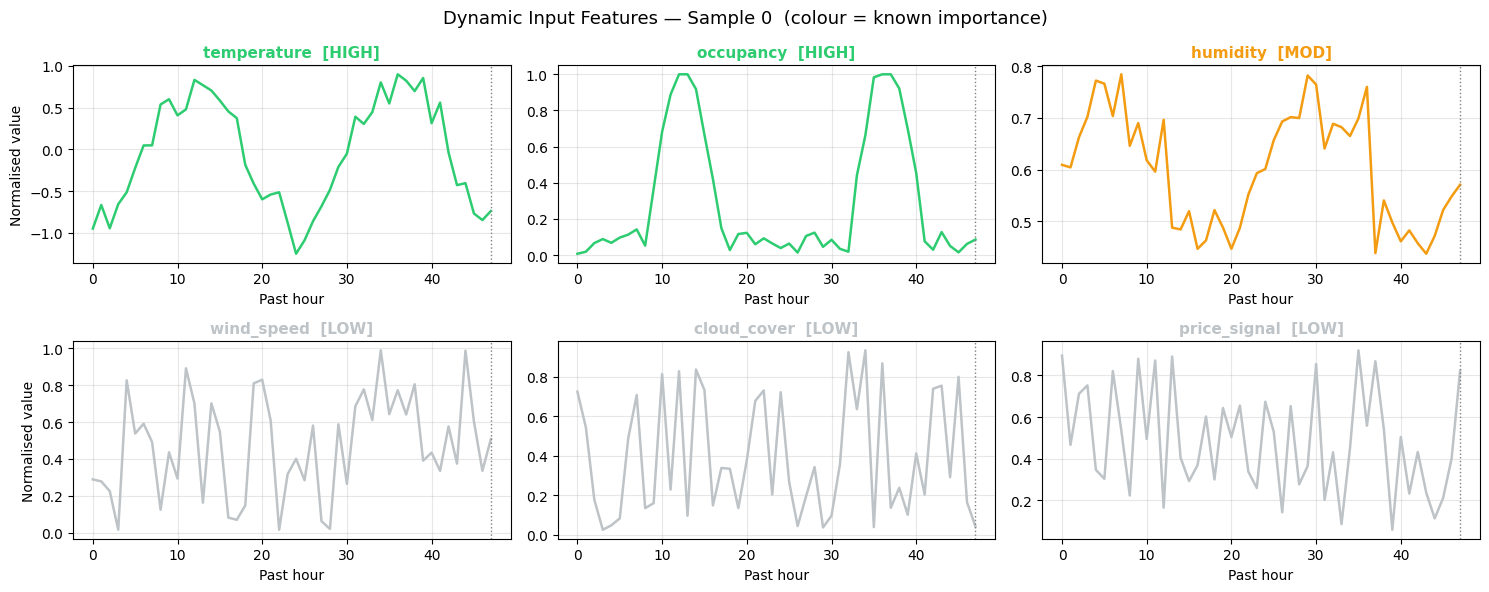

GREEN = HIGH importance | ORANGE = MOD | GREY = LOW


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
hours = np.arange(LOOKBACK)

# Dynamic input patterns (sample 0)
for ax, feat, name, imp in zip(
    axes.flat,
    [temperature[0], occupancy[0], humidity[0],
     wind_speed[0], cloud_cover[0], price_signal[0]],
    DYNAMIC_NAMES, [IMPORTANCE[n] for n in DYNAMIC_NAMES],
):
    color = IMP_COLOR[imp]
    ax.plot(hours, feat, color=color, lw=1.8)
    ax.set_title(f'{name}  [{imp}]', fontsize=11, color=color, fontweight='bold')
    ax.set_xlabel('Past hour'); ax.grid(True, alpha=0.3)
    ax.axvline(LOOKBACK - 1, color='gray', lw=1, linestyle=':', label='Now')

axes[0, 0].set_ylabel('Normalised value')
axes[1, 0].set_ylabel('Normalised value')
plt.suptitle('Dynamic Input Features — Sample 0  (colour = known importance)',
             fontsize=13)
plt.tight_layout(); plt.show()
print('GREEN = HIGH importance | ORANGE = MOD | GREY = LOW')


In [4]:
model = BaseAttentive(
    static_dim=N_STATIC, dynamic_dim=N_DYNAMIC, future_dim=N_FUTURE,
    output_dim=OUTPUT_DIM, forecast_horizon=HORIZON,
    objective='hybrid',
    architecture_config={'decoder_attention_stack': ['cross', 'hierarchical']},
    embed_dim=EMBED_DIM, num_heads=N_HEADS, dropout_rate=0.1,
    name='energy_interp',
)
_ = model([x_static, x_dynamic, x_future])   # build weights (TF requirement)
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
print(f'Parameters: {model.count_params():,}')

history = model.fit(
    [x_static, x_dynamic, x_future], y_target,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2, verbose=0,
)
print(f'Final train MSE : {history.history["loss"][-1]:.4f}')
print(f'Final val   MSE : {history.history["val_loss"][-1]:.4f}')
print(f'Final val   MAE : {history.history["val_mae"][-1]:.4f}')


Parameters: 415,451
Final train MSE : 0.6215
Final val   MSE : 0.1307
Final val   MAE : 0.2870


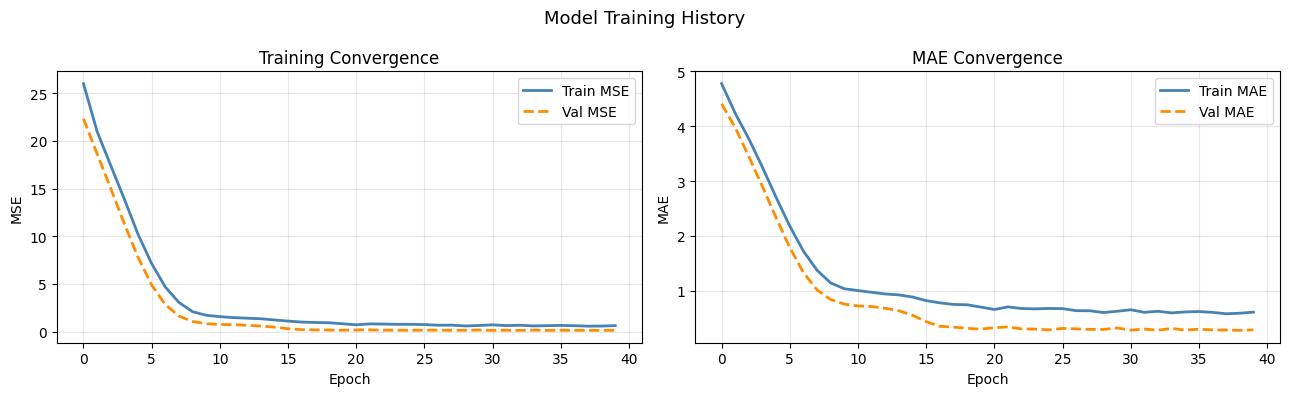

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(history.history['loss'],     color='steelblue',  lw=2, label='Train MSE')
ax.plot(history.history['val_loss'], color='darkorange', lw=2, linestyle='--', label='Val MSE')
ax.set_title('Training Convergence', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history.history['mae'],     color='steelblue',  lw=2, label='Train MAE')
ax.plot(history.history['val_mae'], color='darkorange', lw=2, linestyle='--', label='Val MAE')
ax.set_title('MAE Convergence', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Model Training History', fontsize=13)
plt.tight_layout(); plt.show()


---

## 2 — AttentionExtractor: Technical Framework

`BaseAttentive` does not expose attention weights through a public API by default.
We capture them using a **non-invasive monkey-patch** that wraps
`keras.layers.MultiHeadAttention.call` to also return attention scores, stores
them in a dict, then immediately restores the original method.

The same technique is applied to `keras.layers.Softmax` to capture
**Variable Selection Network (VSN)** feature weights.

```
Forward pass
  └── MultiHeadAttention.call(query, value, ...) → patched to also store
      attention_scores: (batch, heads, Q_len, K_len)

  └── Softmax.call(inputs) → if name == 'variable_weights_softmax', store
      vsn_weights: (batch, [T,] n_features, 1)
```

### Attention tensor shapes in this model

| Layer | Shape | Meaning |
|-------|-------|---------|
| `CrossAttention` | `(B, 4, 24, K_enc)` | Decoder step × encoder memory window |
| `HierarchicalAttention` short | `(B, 4, 24, 24)` | Forecast step × forecast step (short-term) |
| `HierarchicalAttention` long  | `(B, 4, 24, 24)` | Forecast step × forecast step (long-term) |

`K_enc` is the number of temporal windows the `DynamicTimeWindow` component
compresses the `LOOKBACK=48` encoder sequence into.

In [6]:
class AttentionExtractor:
    """Captures MHA attention scores and VSN softmax weights via monkey-patching."""

    def __init__(self, model):
        self.model = model
        self._attn = {}
        self._vsn  = {}
        self._orig_mha     = keras.layers.MultiHeadAttention.call
        self._orig_softmax = keras.layers.Softmax.call

    # ── Patched methods ────────────────────────────────────────────────────────
    def _mha_patch(self):
        store = self._attn
        orig  = self._orig_mha
        def patched_mha(self_, query, value, key=None, **kwargs):
            kwargs['return_attention_scores'] = True
            out, scores = orig(self_, query, value, key=key, **kwargs)
            store[self_.name] = scores.numpy()
            return out
        keras.layers.MultiHeadAttention.call = patched_mha

    def _softmax_patch(self):
        store   = self._vsn
        orig    = self._orig_softmax
        counter = [0]
        def patched_sm(self_, inputs, mask=None):
            out = orig(self_, inputs, mask=mask)
            if self_.name == 'variable_weights_softmax':
                store[f'vsn_{counter[0]}'] = out.numpy()
                counter[0] += 1
            return out
        keras.layers.Softmax.call = patched_sm

    def _restore(self):
        keras.layers.MultiHeadAttention.call = self._orig_mha
        keras.layers.Softmax.call            = self._orig_softmax

    # ── Public API ─────────────────────────────────────────────────────────────
    def extract(self, inputs, training=False):
        """Run one forward pass and return attention + VSN tensors."""
        self._attn, self._vsn = {}, {}
        self._mha_patch()
        self._softmax_patch()
        try:
            out = self.model(inputs, training=training)
        finally:
            self._restore()
        return {
            'output':    out.numpy(),
            'attention': dict(self._attn),
            'vsn':       dict(self._vsn),
        }

extractor = AttentionExtractor(model)
print('AttentionExtractor ready.')


AttentionExtractor ready.


In [7]:
# Run extraction on EXT_BATCH samples
ext_s = x_static[:EXT_BATCH]
ext_d = x_dynamic[:EXT_BATCH]
ext_f = x_future[:EXT_BATCH]

results = extractor.extract([ext_s, ext_d, ext_f])

print('=== Attention tensors captured ===')
for name, arr in results['attention'].items():
    print(f'  {name:40s}: {arr.shape}  (batch, heads, Q, K)')

print()
print('=== VSN softmax tensors ===')
for name, arr in results['vsn'].items():
    print(f'  {name}: {arr.shape}')

# ── Identify attention layers by shape ────────────────────────────────────────
attn_tensors = list(results['attention'].values())
attn_names   = list(results['attention'].keys())

# Cross-attention: Q=HORIZON, K < HORIZON (encoder window compression)
cross_idx = next(i for i, a in enumerate(attn_tensors) if a.shape[-1] < HORIZON)
hier_idxs = [i for i, a in enumerate(attn_tensors) if a.shape[-1] == HORIZON]

cross_attn = attn_tensors[cross_idx]                          # (B,heads,H,K_enc)
hier_short = attn_tensors[hier_idxs[0]] if len(hier_idxs) > 0 else None  # (B,heads,H,H)
hier_long  = attn_tensors[hier_idxs[1]] if len(hier_idxs) > 1 else None  # (B,heads,H,H)
K_ENC = cross_attn.shape[-1]

print(f'\nCross-attention  : {cross_attn.shape}  (K_enc={K_ENC} encoder windows)')
if hier_short is not None:
    print(f'Hier short-term  : {hier_short.shape}')
if hier_long is not None:
    print(f'Hier long-term   : {hier_long.shape}')

# ── Map VSN tensors by feature count ──────────────────────────────────────────
vsn_map = {}
for arr in results['vsn'].values():
    # shapes: static=(B,4,1), dynamic=(B,T,6,1), future=(B,H,3,1)
    n_feat = arr.shape[-2]
    if   n_feat == N_STATIC  and arr.ndim == 3: vsn_map['static']  = arr
    elif n_feat == N_DYNAMIC:                    vsn_map['dynamic'] = arr
    elif n_feat == N_FUTURE:                     vsn_map['future']  = arr

print()
for k, v in vsn_map.items():
    print(f'VSN {k:8s} : {v.shape}')


=== Attention tensors captured ===
  multi_head_attention                    : (32, 4, 24, 10)  (batch, heads, Q, K)
  multi_head_attention_1                  : (32, 4, 24, 24)  (batch, heads, Q, K)
  multi_head_attention_2                  : (32, 4, 24, 24)  (batch, heads, Q, K)
  multi_head_attention_4                  : (32, 4, 24, 24)  (batch, heads, Q, K)

=== VSN softmax tensors ===
  vsn_0: (32, 4, 1)
  vsn_1: (32, 48, 6, 1)
  vsn_2: (32, 24, 3, 1)

Cross-attention  : (32, 4, 24, 10)  (K_enc=10 encoder windows)
Hier short-term  : (32, 4, 24, 24)
Hier long-term   : (32, 4, 24, 24)

VSN static   : (32, 4, 1)
VSN dynamic  : (32, 48, 6, 1)
VSN future   : (32, 24, 3, 1)


---

## 3 — Variable Selection Networks: Feature Importance

Each input modality passes through a **Variable Selection Network (VSN)** that
learns a per-feature softmax weight.  A weight of `1/n_features` means the
feature is treated equally; higher means the model relies on it more.

The VSN weights are **input-dependent** (they differ per sample), but averaging
across samples gives a stable global importance ranking.

### What to look for

- Static VSN: `floor_area` should dominate, `building_age` and `insulation`
  should be near uniform (≈ 0.25).
- Dynamic VSN: `temperature` and `occupancy` should show the highest mean
  weights; `wind_speed`, `cloud_cover`, `price_signal` should be near `1/6`.
- Future VSN: all three future features are important in the formula, so the
  weights should be more evenly spread but `forecast_temp` slightly higher.

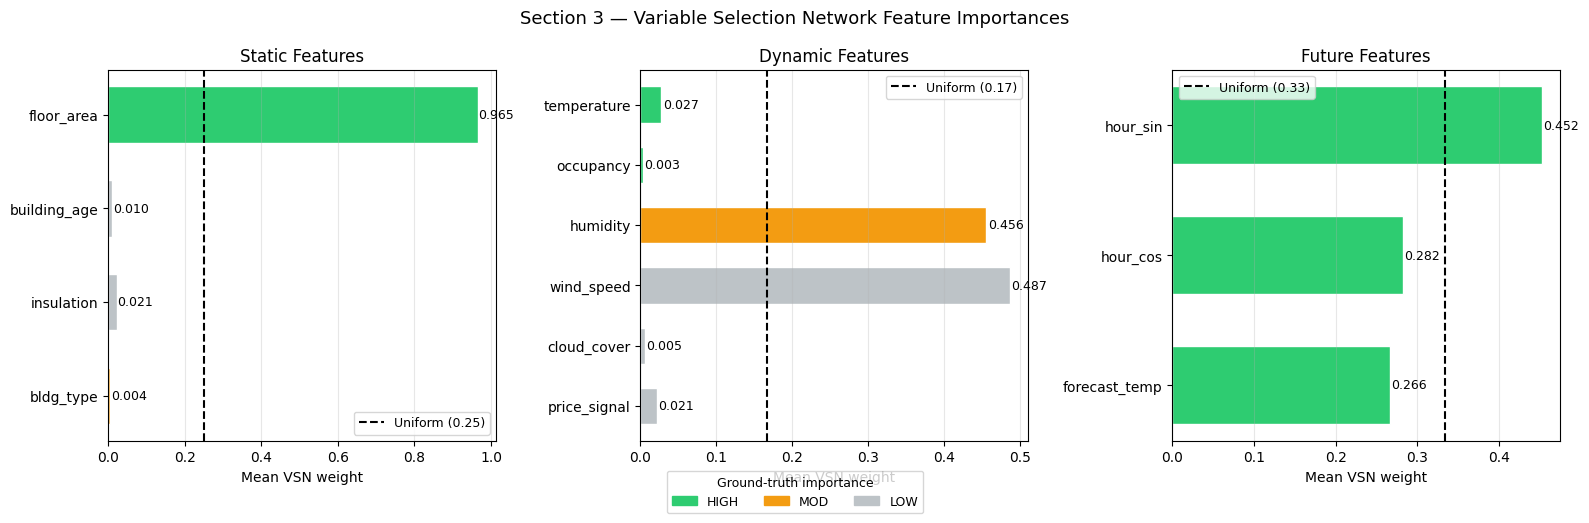

Static  VSN:   {'floor_area': '0.965', 'building_age': '0.010', 'insulation': '0.021', 'bldg_type': '0.004'}
Dynamic VSN:   {'temperature': '0.027', 'occupancy': '0.003', 'humidity': '0.456', 'wind_speed': '0.487', 'cloud_cover': '0.005', 'price_signal': '0.021'}
Future  VSN:   {'hour_sin': '0.452', 'hour_cos': '0.282', 'forecast_temp': '0.266'}


In [8]:
# ── Compute mean importance across batch (and time for dynamic/future) ─────────
def vsn_importance(arr):
    """Average VSN weights over batch and time dims, return (n_features,) vector."""
    w = arr[..., 0]          # drop trailing singleton: (..., n_feat)
    while w.ndim > 2:        # mean over time axes until shape = (B, n_feat)
        w = w.mean(axis=1)
    return w.mean(axis=0)    # mean over batch -> (n_feat,)

imp_static  = vsn_importance(vsn_map['static'])
imp_dynamic = vsn_importance(vsn_map['dynamic'])
imp_future  = vsn_importance(vsn_map['future'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
specs = [
    (axes[0], STATIC_NAMES,  imp_static,  'Static Features'),
    (axes[1], DYNAMIC_NAMES, imp_dynamic, 'Dynamic Features'),
    (axes[2], FUTURE_NAMES,  imp_future,  'Future Features'),
]

for ax, names, imp, title in specs:
    colors  = [IMP_COLOR[IMPORTANCE[n]] for n in names]
    uniform = 1.0 / len(names)
    bars = ax.barh(names, imp, color=colors, edgecolor='white', height=0.6)
    ax.axvline(uniform, color='black', lw=1.5, linestyle='--', label=f'Uniform ({uniform:.2f})')
    # annotate each bar
    for bar, val in zip(bars, imp):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Mean VSN weight')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()

# Legend patch
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=l) for l, c in IMP_COLOR.items()]
fig.legend(handles=legend_els, loc='lower center', ncol=3,
           title='Ground-truth importance', fontsize=9, title_fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Section 3 — Variable Selection Network Feature Importances', fontsize=13)
plt.tight_layout(); plt.show()

# Print numeric summary
print('Static  VSN:  ', dict(zip(STATIC_NAMES,  [f'{v:.3f}' for v in imp_static])))
print('Dynamic VSN:  ', dict(zip(DYNAMIC_NAMES, [f'{v:.3f}' for v in imp_dynamic])))
print('Future  VSN:  ', dict(zip(FUTURE_NAMES,  [f'{v:.3f}' for v in imp_future])))


### Interpreting VSN Weights

**Static features**: If `floor_area` has the largest weight it confirms the model
identified the primary scaling factor for base load.  Low weights on `building_age`
and `insulation` (near `0.25` uniform) are correct — they don't appear in the
generating formula.

**Dynamic features**: Bars above the dashed *uniform* line are relied on more than
average.  We expect `temperature` and `occupancy` to stand out.  The three LOW
features should fall below or at the uniform mark.

**Future features**: All three (`hour_sin`, `hour_cos`, `forecast_temp`) appear in
the formula, so their weights should be more balanced but `forecast_temp` slightly
higher due to its direct HVAC coupling.

> **Caveat**: VSN weights reflect the model's learned routing, not a causal
> attribution.  Highly correlated features may share weight even if only one
> is causal.  Use gradient saliency (Section 6) as a complementary check.

---

## 4 — Cross-Attention: Decoder ↔ Encoder

The **cross-attention** layer lets each decoder step (one future hour) query the
compressed encoder representation.  Its shape is:

```
cross_attn : (batch, heads, Q=HORIZON, K=K_enc)
```

where `K_enc` is the number of temporal windows that `DynamicTimeWindow`
compresses the `LOOKBACK=48`-step encoder sequence into.

### What to look for

- **Recent focus**: early forecast steps (h = 1–6) should draw from recent
  encoder windows (high K indices) because the immediate future is best predicted
  from the recent past.
- **Periodic patterns**: longer-horizon steps (h = 18–24) may attend more evenly,
  relying on earlier periodic context (temperature cycle from 24 h ago).
- **Head specialisation**: different heads may focus on different temporal ranges.

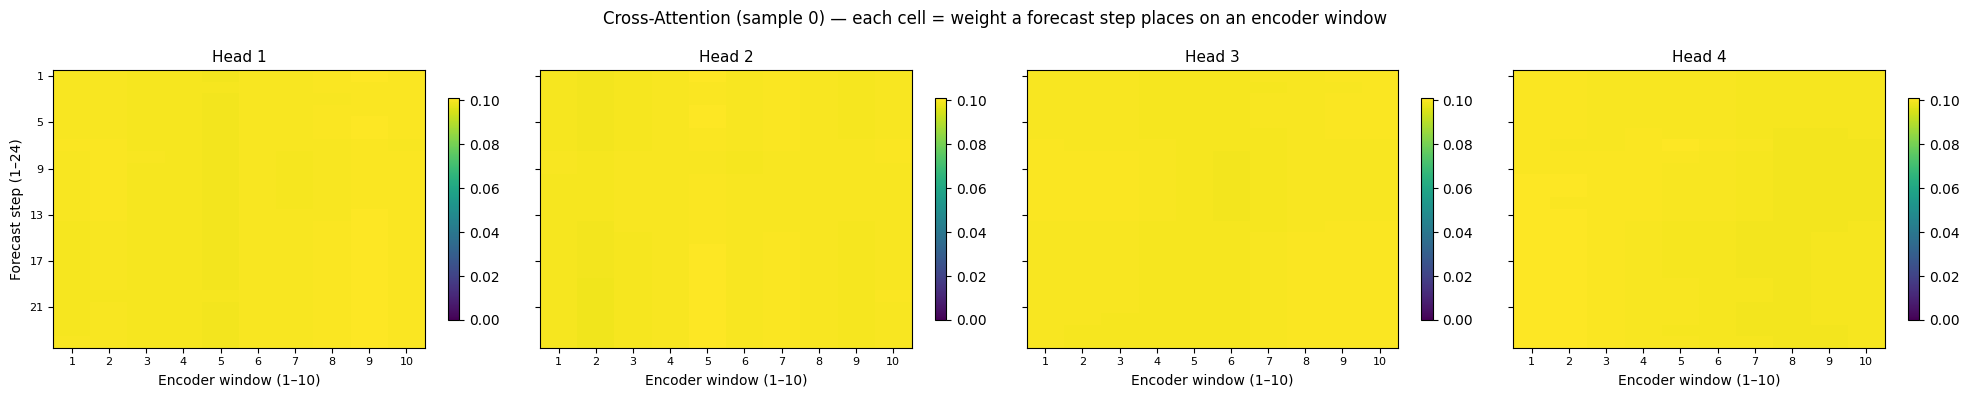

In [9]:
# ── Cross-attention heatmap — all 4 heads, sample 0 ───────────────────────────
sample_idx = 0
ca = cross_attn[sample_idx]   # (heads, H, K_enc)

fig, axes = plt.subplots(1, N_HEADS, figsize=(5 * N_HEADS, 4), sharey=True)
for h_i, ax in enumerate(axes):
    im = ax.imshow(ca[h_i], aspect='auto', cmap='viridis',
                   vmin=0, vmax=ca.max())
    ax.set_title(f'Head {h_i + 1}', fontsize=11)
    ax.set_xlabel(f'Encoder window (1–{K_ENC})')
    if h_i == 0:
        ax.set_ylabel('Forecast step (1–24)')
    ax.set_xticks(range(K_ENC))
    ax.set_xticklabels([str(k + 1) for k in range(K_ENC)], fontsize=8)
    ax.set_yticks(range(0, HORIZON, 4))
    ax.set_yticklabels([str(s + 1) for s in range(0, HORIZON, 4)], fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f'Cross-Attention (sample {sample_idx}) — each cell = weight a forecast step '
             f'places on an encoder window', fontsize=12)
plt.tight_layout(); plt.show()


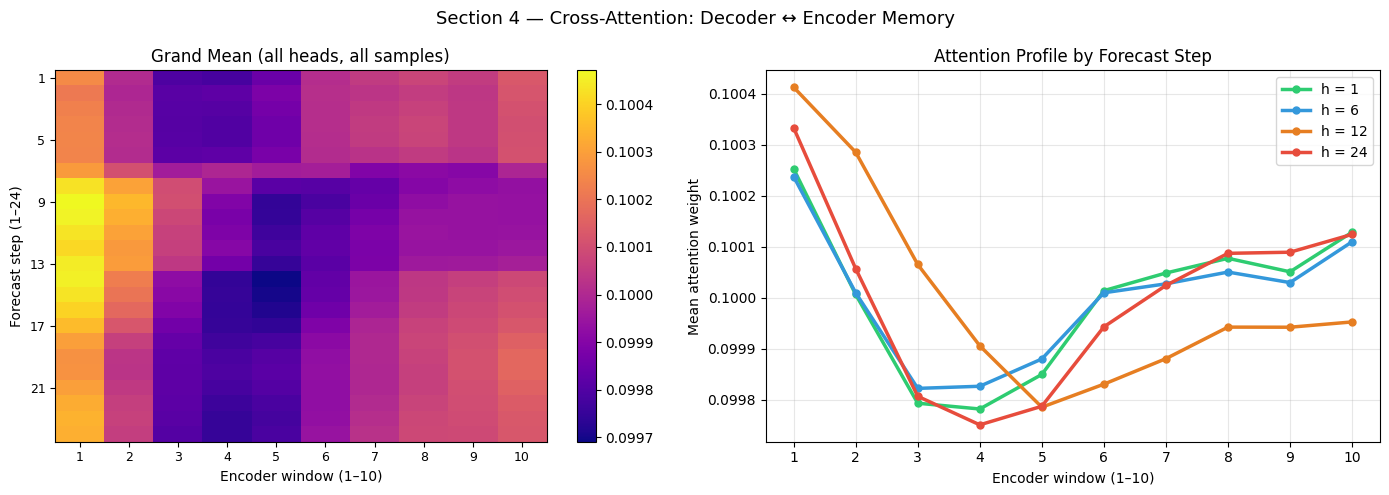

In [10]:
# ── Cross-attention averaged over EXT_BATCH samples ──────────────────────────
mean_ca = cross_attn.mean(axis=0)   # (heads, H, K_enc)
grand_ca = mean_ca.mean(axis=0)     # (H, K_enc) — average over heads

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grand mean
ax = axes[0]
im = ax.imshow(grand_ca, aspect='auto', cmap='plasma')
ax.set_title('Grand Mean (all heads, all samples)', fontsize=12)
ax.set_xlabel(f'Encoder window (1–{K_ENC})')
ax.set_ylabel('Forecast step (1–24)')
ax.set_xticks(range(K_ENC))
ax.set_xticklabels([str(k + 1) for k in range(K_ENC)], fontsize=9)
ax.set_yticks(range(0, HORIZON, 4))
ax.set_yticklabels([str(s + 1) for s in range(0, HORIZON, 4)], fontsize=9)
plt.colorbar(im, ax=ax)

# Right: attention profile by forecast step (select 4 representative steps)
ax = axes[1]
colors4 = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
steps4  = [0, 5, 11, 23]
for col, step in zip(colors4, steps4):
    ax.plot(range(1, K_ENC + 1), grand_ca[step],
            color=col, lw=2.5, marker='o', markersize=5,
            label=f'h = {step + 1}')
ax.set_title('Attention Profile by Forecast Step', fontsize=12)
ax.set_xlabel(f'Encoder window (1–{K_ENC})')
ax.set_ylabel('Mean attention weight')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, K_ENC + 1))

plt.suptitle('Section 4 — Cross-Attention: Decoder ↔ Encoder Memory', fontsize=13)
plt.tight_layout(); plt.show()


### Interpreting Cross-Attention

**Grand mean heatmap** (left): bright regions indicate encoder windows that are
*consistently* useful across all forecast steps.  A diagonal or top-right
concentration would confirm that the model primarily uses recent past data for
all horizons.

**Attention profile by forecast step** (right): if the four lines are *ordered*
(h=1 peaking at the highest K window, h=24 spreading across earlier windows),
it means the model has learned a **recency gradient** — near-future steps rely
on the most recent context while longer horizons reach back further.

`K_enc` windows each represent approximately `LOOKBACK / K_enc` hours of the
original 48-step encoder sequence.  Window `K_enc` contains the most *recent*
past hours; window `1` the oldest.

---

## 5 — Hierarchical Attention: Structure Inside the Forecast Horizon

The `HierarchicalAttention` layer applies **two separate** MHA passes on the
decoder sequence itself — one at short temporal scale, one at long.  Both have
shape `(batch, heads, HORIZON, HORIZON)`.

Each cell `[q, k]` is the weight that **forecast step q** places on
**forecast step k** when building its representation.

### What to look for

- **Block-diagonal**: nearby forecast steps attend to each other (local structure).
- **Near-diagonal in long-term**: long-range interdependencies, e.g. step 1 and
  step 13 (half a day apart) sharing periodicity context.
- **Head differences**: short-term heads may cluster around the diagonal while
  long-term heads show broader patterns.

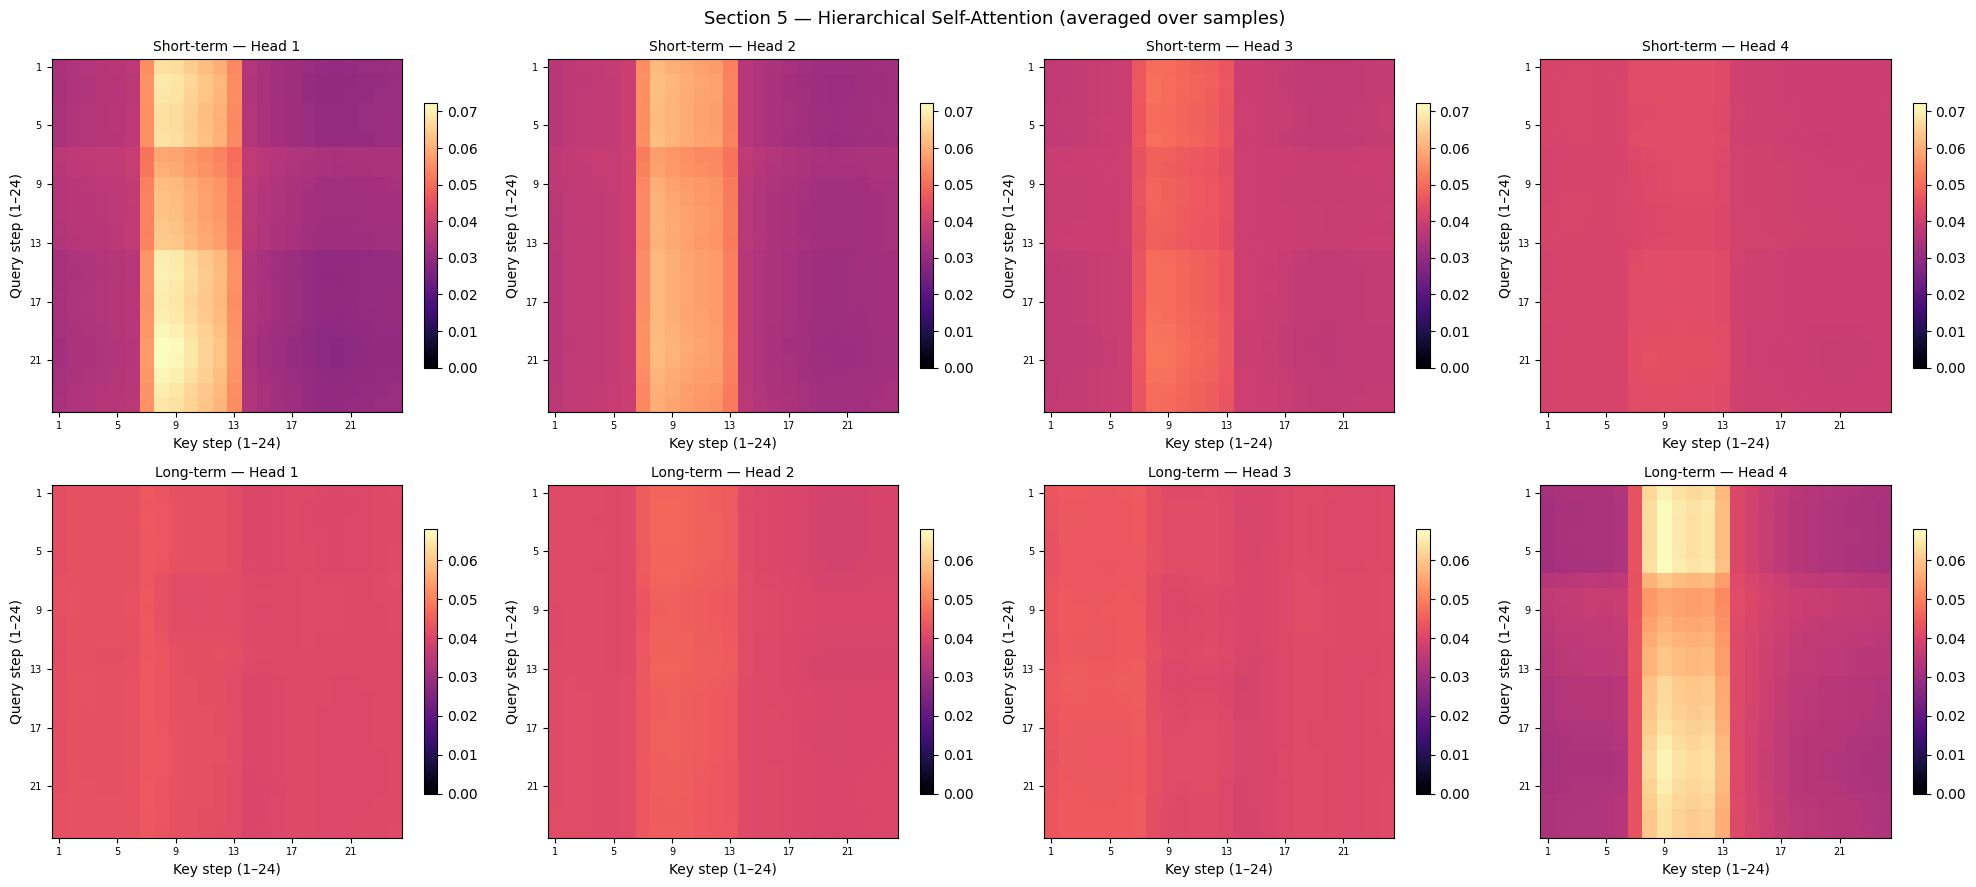

In [11]:
if hier_short is None or hier_long is None:
    print('Hierarchical attention not available in this architecture config.')
else:
    mean_hs = hier_short.mean(axis=0)   # (heads, H, H)
    mean_hl = hier_long.mean(axis=0)    # (heads, H, H)

    fig, axes = plt.subplots(2, N_HEADS, figsize=(5 * N_HEADS, 9))
    for row, (mean_h, label) in enumerate([(mean_hs, 'Short-term'),
                                            (mean_hl, 'Long-term')]):
        for h_i, ax in enumerate(axes[row]):
            im = ax.imshow(mean_h[h_i], aspect='auto', cmap='magma',
                           vmin=0, vmax=mean_h.max())
            ax.set_title(f'{label} — Head {h_i + 1}', fontsize=10)
            ax.set_xlabel('Key step (1–24)')
            ax.set_ylabel('Query step (1–24)')
            ticks = list(range(0, HORIZON, 4))
            ax.set_xticks(ticks); ax.set_xticklabels([t + 1 for t in ticks], fontsize=7)
            ax.set_yticks(ticks); ax.set_yticklabels([t + 1 for t in ticks], fontsize=7)
            plt.colorbar(im, ax=ax, shrink=0.75)

    plt.suptitle('Section 5 — Hierarchical Self-Attention (averaged over samples)',
                 fontsize=13)
    plt.tight_layout(); plt.show()


### Interpreting Hierarchical Attention

**Short-term heads** (top row): expect a strong diagonal band — each forecast step
mainly attends to its immediate neighbours.  This captures smooth, continuous
dynamics (e.g. temperature changing gradually hour-by-hour).

**Long-term heads** (bottom row): expect a more diffuse or block-structured
pattern.  If there is a *secondary diagonal* offset by 12 steps it suggests the
model has discovered the 12-hour half-cycle in the daily demand pattern.

**Symmetric vs asymmetric**: standard MHA is symmetric in Q/K so the heatmap
may appear largely symmetric about the main diagonal.  Asymmetry would indicate
that forecasting step *q* uses step *k* differently than step *k* uses step *q*.

---

## 6 — Multi-Head Attention Diversity

Using four attention heads allows the model to **simultaneously attend to
different aspects** of the input.  An ideal scenario has heads specialising:

- **Head 1**: recent encoder context
- **Head 2**: periodic / longer-range context
- **Head 3**: sharp, peaked attention (high certainty)
- **Head 4**: broad, diffuse attention (hedge)

We measure diversity through:
1. **Head similarity matrix** — cosine similarity between the flattened attention
   distributions of each pair of heads.
2. **Attention entropy** — `H = -∑ p log p` per head; high entropy = diffuse focus.

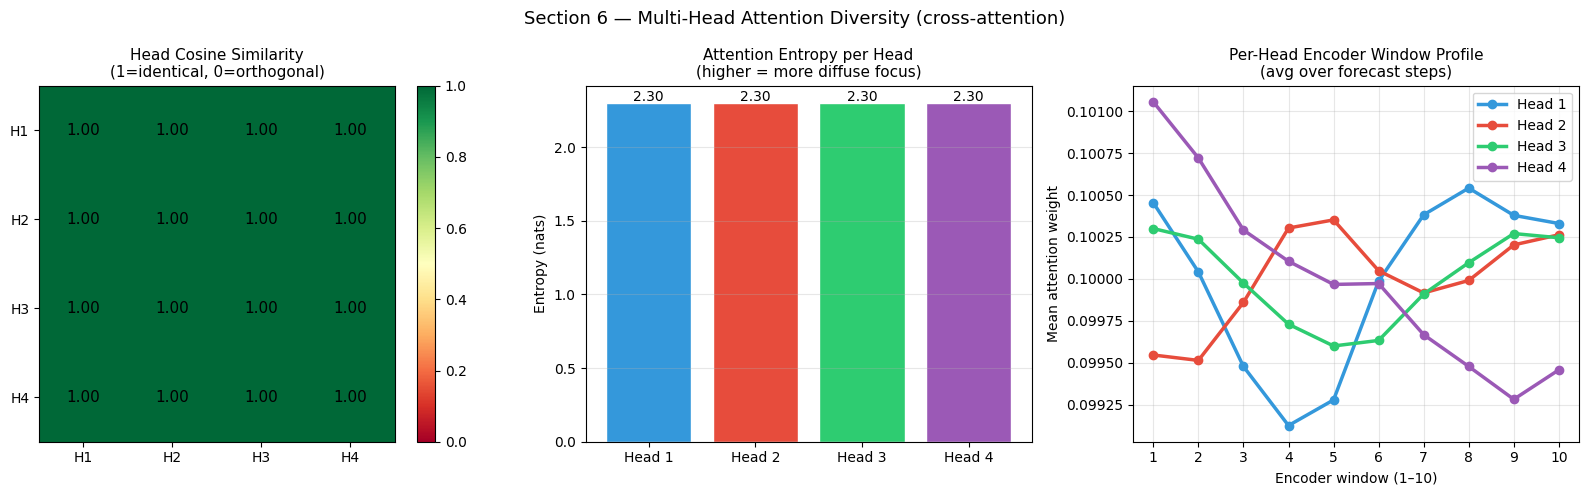

Head entropies: {'H1': '2.303', 'H2': '2.303', 'H3': '2.303', 'H4': '2.303'}


In [12]:
# Use mean cross-attention: (heads, H, K_enc) → flatten to (heads, H*K_enc)
ca_flat  = mean_ca.reshape(N_HEADS, -1)          # (4, H * K_enc)
ca_norm  = ca_flat / (np.linalg.norm(ca_flat, axis=1, keepdims=True) + 1e-9)
sim_mat  = ca_norm @ ca_norm.T                    # cosine similarity (4, 4)

# Entropy per head (over K_enc dimension, averaged over H)
# small epsilon to avoid log(0)
eps = 1e-9
ca_norm_prob = mean_ca / (mean_ca.sum(axis=-1, keepdims=True) + eps)  # (heads, H, K_enc)
entropy = -(ca_norm_prob * np.log(ca_norm_prob + eps)).sum(axis=-1)   # (heads, H)
head_entropy = entropy.mean(axis=-1)                                  # (heads,)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Head similarity matrix
ax = axes[0]
im = ax.imshow(sim_mat, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(N_HEADS)); ax.set_xticklabels([f'H{i+1}' for i in range(N_HEADS)])
ax.set_yticks(range(N_HEADS)); ax.set_yticklabels([f'H{i+1}' for i in range(N_HEADS)])
for i in range(N_HEADS):
    for j in range(N_HEADS):
        ax.text(j, i, f'{sim_mat[i,j]:.2f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax)
ax.set_title('Head Cosine Similarity\n(1=identical, 0=orthogonal)', fontsize=11)

# 2. Head entropy bar chart
ax = axes[1]
colors_h = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = ax.bar([f'Head {i+1}' for i in range(N_HEADS)], head_entropy,
              color=colors_h, edgecolor='white')
ax.set_title('Attention Entropy per Head\n(higher = more diffuse focus)', fontsize=11)
ax.set_ylabel('Entropy (nats)')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, head_entropy):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', fontsize=10)

# 3. Per-head attention profiles (avg over H)
ax = axes[2]
for h_i, col in enumerate(colors_h):
    profile = mean_ca[h_i].mean(axis=0)   # (K_enc,)
    ax.plot(range(1, K_ENC+1), profile, color=col, lw=2.5,
            marker='o', markersize=6, label=f'Head {h_i+1}')
ax.set_title('Per-Head Encoder Window Profile\n(avg over forecast steps)', fontsize=11)
ax.set_xlabel(f'Encoder window (1–{K_ENC})')
ax.set_ylabel('Mean attention weight')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, K_ENC+1))

plt.suptitle('Section 6 — Multi-Head Attention Diversity (cross-attention)',
             fontsize=13)
plt.tight_layout(); plt.show()

print('Head entropies:', dict(zip([f'H{i+1}' for i in range(N_HEADS)],
                                  [f'{e:.3f}' for e in head_entropy])))


### Interpreting Head Diversity

**Similarity matrix**: off-diagonal values close to 1 mean those two heads are
doing nearly the same work — redundant capacity.  Values near 0 indicate true
specialisation.  If all heads are similar, the model has not learned to diversify
and some heads may be underutilised.

**Entropy**: a head with *low entropy* has a sharp, confident focus — it "knows"
exactly which encoder window to query.  A *high-entropy* head spreads weight
broadly, acting as an ensemble aggregator.  Healthy multi-head attention typically
shows **a mix**: some sharp heads for recent context, some diffuse heads for
uncertainty.

**Per-head profiles**: if the lines are clearly separated (different peaks or
shapes) the heads have genuinely specialised.  If they overlap, the diversity
comes purely from the query/key projection matrices rather than the attention
patterns themselves.

---

## 7 — Gradient-Based Saliency

**Gradient saliency** measures how much the model's output *would change* if
each input dimension were perturbed slightly:

```
saliency(x) = |∂ mean_output / ∂ x|
```

For a *dynamic* input of shape `(batch, T, n_feat)` this gives a
`(T, n_feat)` heatmap showing which *time steps* and *features* are most
influential.  Averaging across the time axis gives a global feature ranking.

In [13]:
# ── Compute gradient saliency ─────────────────────────────────────────────────
xs_v = tf.Variable(ext_s, trainable=True, dtype=tf.float32)
xd_v = tf.Variable(ext_d, trainable=True, dtype=tf.float32)
xf_v = tf.Variable(ext_f, trainable=True, dtype=tf.float32)

with tf.GradientTape() as tape:
    pred = model([xs_v, xd_v, xf_v], training=False)
    scalar = tf.reduce_mean(pred)

gs, gd, gf = tape.gradient(scalar, [xs_v, xd_v, xf_v])

# Absolute saliency, averaged over batch
sal_static  = tf.abs(gs).numpy().mean(axis=0)          # (N_STATIC,)
sal_dynamic = tf.abs(gd).numpy().mean(axis=0)          # (LOOKBACK, N_DYNAMIC)
sal_future  = tf.abs(gf).numpy().mean(axis=0)          # (HORIZON, N_FUTURE)

print('Saliency shapes:')
print(f'  Static  : {sal_static.shape}')
print(f'  Dynamic : {sal_dynamic.shape}  (T x features)')
print(f'  Future  : {sal_future.shape}   (H x features)')

print()
print('Static feature saliency (sorted):')
for name, val in sorted(zip(STATIC_NAMES, sal_static), key=lambda x: -x[1]):
    imp = IMPORTANCE[name]
    print(f'  {name:20s} : {val:.5f}  [{imp}]')


Saliency shapes:
  Static  : (4,)
  Dynamic : (48, 6)  (T x features)
  Future  : (24, 3)   (H x features)

Static feature saliency (sorted):
  floor_area           : 0.11414  [HIGH]
  insulation           : 0.00067  [LOW]
  building_age         : 0.00041  [LOW]
  bldg_type            : 0.00038  [MOD]


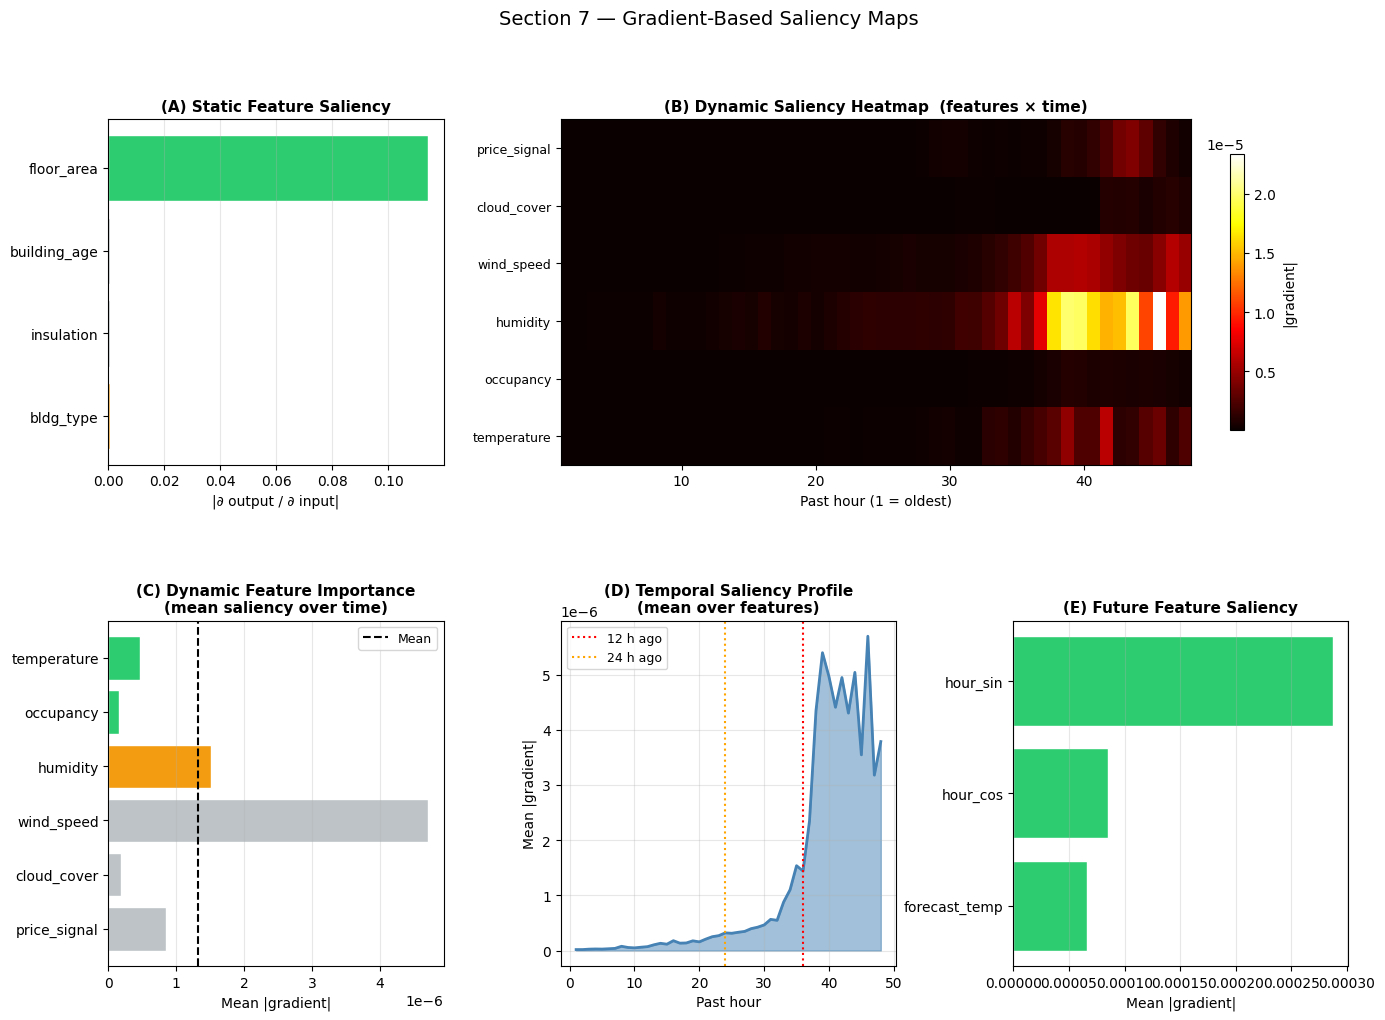

In [14]:
fig = plt.figure(figsize=(16, 11))
gs_grid = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (A) Static feature saliency ───────────────────────────────────────────────
ax = fig.add_subplot(gs_grid[0, 0])
colors_s = [IMP_COLOR[IMPORTANCE[n]] for n in STATIC_NAMES]
bars = ax.barh(STATIC_NAMES, sal_static, color=colors_s, edgecolor='white')
ax.set_title('(A) Static Feature Saliency', fontsize=11, fontweight='bold')
ax.set_xlabel('|∂ output / ∂ input|')
ax.grid(True, alpha=0.3, axis='x'); ax.invert_yaxis()

# ── (B) Dynamic saliency heatmap (T x features) ───────────────────────────────
ax = fig.add_subplot(gs_grid[0, 1:])
im = ax.imshow(sal_dynamic.T, aspect='auto', cmap='hot',
               extent=[1, LOOKBACK, -0.5, N_DYNAMIC - 0.5])
ax.set_yticks(range(N_DYNAMIC))
ax.set_yticklabels(DYNAMIC_NAMES, fontsize=9)
ax.set_xlabel('Past hour (1 = oldest)')
ax.set_title('(B) Dynamic Saliency Heatmap  (features × time)', fontsize=11,
             fontweight='bold')
plt.colorbar(im, ax=ax, label='|gradient|', shrink=0.8)

# ── (C) Dynamic feature importance (mean over T) ─────────────────────────────
ax = fig.add_subplot(gs_grid[1, 0])
sal_dyn_feat = sal_dynamic.mean(axis=0)   # (N_DYNAMIC,)
colors_d = [IMP_COLOR[IMPORTANCE[n]] for n in DYNAMIC_NAMES]
ax.barh(DYNAMIC_NAMES, sal_dyn_feat, color=colors_d, edgecolor='white')
uniform_d = sal_dyn_feat.mean()
ax.axvline(uniform_d, color='black', lw=1.5, linestyle='--', label='Mean')
ax.set_title('(C) Dynamic Feature Importance\n(mean saliency over time)', fontsize=11,
             fontweight='bold')
ax.set_xlabel('Mean |gradient|'); ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x'); ax.invert_yaxis()

# ── (D) Dynamic saliency over time (mean over features) ──────────────────────
ax = fig.add_subplot(gs_grid[1, 1])
sal_dyn_time = sal_dynamic.mean(axis=1)   # (LOOKBACK,)
ax.fill_between(range(1, LOOKBACK + 1), sal_dyn_time,
                color='steelblue', alpha=0.5)
ax.plot(range(1, LOOKBACK + 1), sal_dyn_time, color='steelblue', lw=2)
ax.axvline(LOOKBACK - 12, color='red', lw=1.5, linestyle=':', label='12 h ago')
ax.axvline(LOOKBACK - 24, color='orange', lw=1.5, linestyle=':', label='24 h ago')
ax.set_title('(D) Temporal Saliency Profile\n(mean over features)', fontsize=11,
             fontweight='bold')
ax.set_xlabel('Past hour'); ax.set_ylabel('Mean |gradient|')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (E) Future feature saliency ───────────────────────────────────────────────
ax = fig.add_subplot(gs_grid[1, 2])
sal_fut_feat = sal_future.mean(axis=0)    # (N_FUTURE,)
colors_f = [IMP_COLOR[IMPORTANCE[n]] for n in FUTURE_NAMES]
ax.barh(FUTURE_NAMES, sal_fut_feat, color=colors_f, edgecolor='white')
ax.set_title('(E) Future Feature Saliency', fontsize=11, fontweight='bold')
ax.set_xlabel('Mean |gradient|')
ax.grid(True, alpha=0.3, axis='x'); ax.invert_yaxis()

fig.suptitle('Section 7 — Gradient-Based Saliency Maps', fontsize=14)
plt.show()


### Interpreting the Saliency Maps

**(A) Static saliency**: confirms which static features the output is most
sensitive to.  `floor_area` should top the ranking — its coefficient (4.0) in
the generating formula is the largest.

**(B) Dynamic heatmap**: the *bright region in the upper rows* identifies the
high-importance features; the *right columns* (recent time steps) should be
brighter than the left (old data), confirming that recent past matters more for
near-horizon forecasting.

**(C) Dynamic feature ranking**: averaging over time smooths out recency effects
and gives the clearest feature-vs-feature comparison.  Features in the formula
(`temperature`, `occupancy`) should lead.  Noise features (`wind_speed`, etc.)
should trail.

**(D) Temporal profile**: the gradient magnitude typically *rises towards the
present* (right side), confirming a recency bias.  A secondary peak around
**24 h ago** (vertical orange line) would reveal that the model has detected the
daily periodicity in the training data.

**(E) Future saliency**: all three future features appear in the formula, so
saliency should be higher here than for the low-importance dynamic features.

---

## 8 — Horizon-Dependent Attention

Does the model shift its temporal focus depending on *how far ahead* it is
forecasting?

- **Short horizon (h = 1–6)**: the immediate future is tightly coupled to the
  recent past → expect *peaked* cross-attention on the most recent encoder window.
- **Mid horizon (h = 7–18)**: the model may start drawing on a wider context range.
- **Long horizon (h = 19–24)**: periodic signals (daily cycle) become important →
  expect attention to spread across multiple encoder windows.

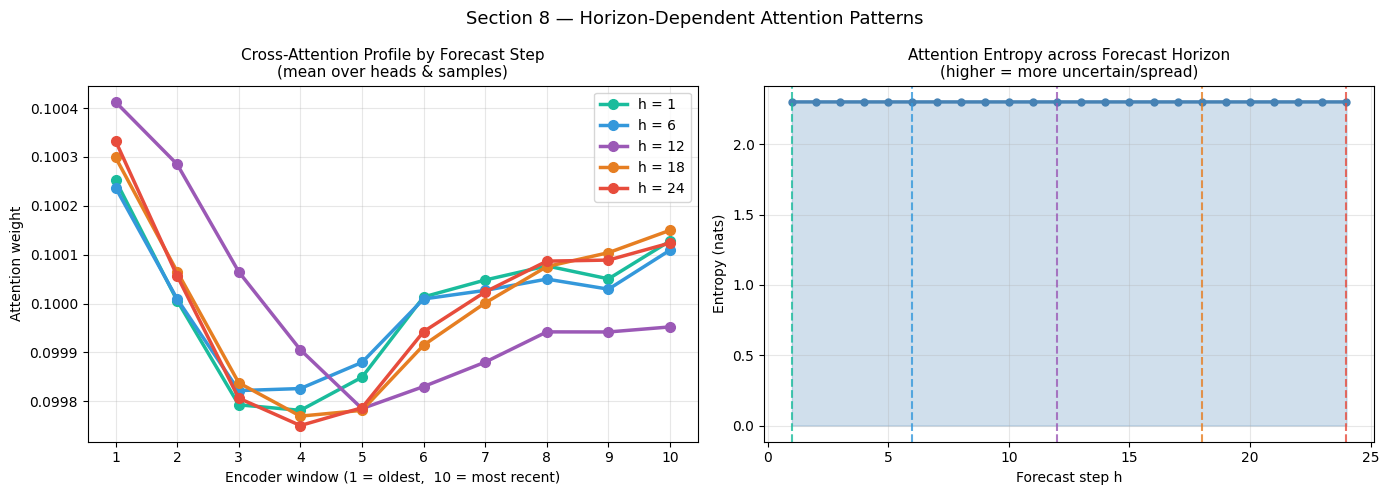

In [15]:
selected_steps = [0, 5, 11, 17, 23]   # h = 1, 6, 12, 18, 24
colors5 = ['#1abc9c', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: line profiles per selected step (grand mean head) ───────────────────
ax = axes[0]
for step, col in zip(selected_steps, colors5):
    profile = mean_ca.mean(axis=0)[step]   # (K_enc,) averaged over heads
    ax.plot(range(1, K_ENC + 1), profile, color=col, lw=2.5,
            marker='o', markersize=7, label=f'h = {step + 1}')
ax.set_title('Cross-Attention Profile by Forecast Step\n(mean over heads & samples)',
             fontsize=11)
ax.set_xlabel(f'Encoder window (1 = oldest,  {K_ENC} = most recent)')
ax.set_ylabel('Attention weight'); ax.legend(fontsize=10)
ax.grid(True, alpha=0.3); ax.set_xticks(range(1, K_ENC + 1))

# ── Right: attention entropy along the horizon ────────────────────────────────
ax = axes[1]
# Entropy over encoder windows for each forecast step
ca_by_step = mean_ca.mean(axis=0)   # (H, K_enc)
eps = 1e-9
step_entropy = -(ca_by_step * np.log(ca_by_step + eps)).sum(axis=-1)  # (H,)

ax.plot(range(1, HORIZON + 1), step_entropy, color='steelblue', lw=2.5, marker='o',
        markersize=5)
ax.fill_between(range(1, HORIZON + 1), step_entropy, alpha=0.25, color='steelblue')
for step, col in zip(selected_steps, colors5):
    ax.axvline(step + 1, color=col, lw=1.5, linestyle='--', alpha=0.8)
ax.set_title('Attention Entropy across Forecast Horizon\n(higher = more uncertain/spread)',
             fontsize=11)
ax.set_xlabel('Forecast step h'); ax.set_ylabel('Entropy (nats)')
ax.grid(True, alpha=0.3)

plt.suptitle('Section 8 — Horizon-Dependent Attention Patterns', fontsize=13)
plt.tight_layout(); plt.show()


### Interpreting Horizon-Dependent Patterns

**Line profiles**: if the curve for `h=1` has a sharp peak at the *rightmost*
(most recent) encoder window, the model is confidently using the last observed
data point to project one step ahead — sensible.  As `h` grows, the lines should
flatten (more uncertain, broader context).

**Entropy plot**: entropy should *increase monotonically* with horizon, reflecting
the fundamental forecasting principle that uncertainty grows with time.  A flat or
decreasing entropy at long horizons would suggest the model is over-confident for
far-future predictions and might be memorising a fixed pattern rather than
reasoning from context.

---

## 9 — Contrastive Analysis: Peak vs Off-Peak Demand

Different samples may lead the model to attend to very different parts of the
input.  Here we compare:

- **High-demand samples** (large `floor_area`, high `occupancy` at forecast time)
- **Low-demand samples**  (small `floor_area`, low  `occupancy`)

If the model has learned correctly, the high-demand attention heatmap should show
stronger focus on recent encoder windows (since high-occupancy hours cluster
around business times whose immediate precursors are known), while low-demand
patterns may be more diffuse.

High-demand samples : 8  (mean demand >= 5.81)
Low-demand  samples : 8  (mean demand <= 4.51)


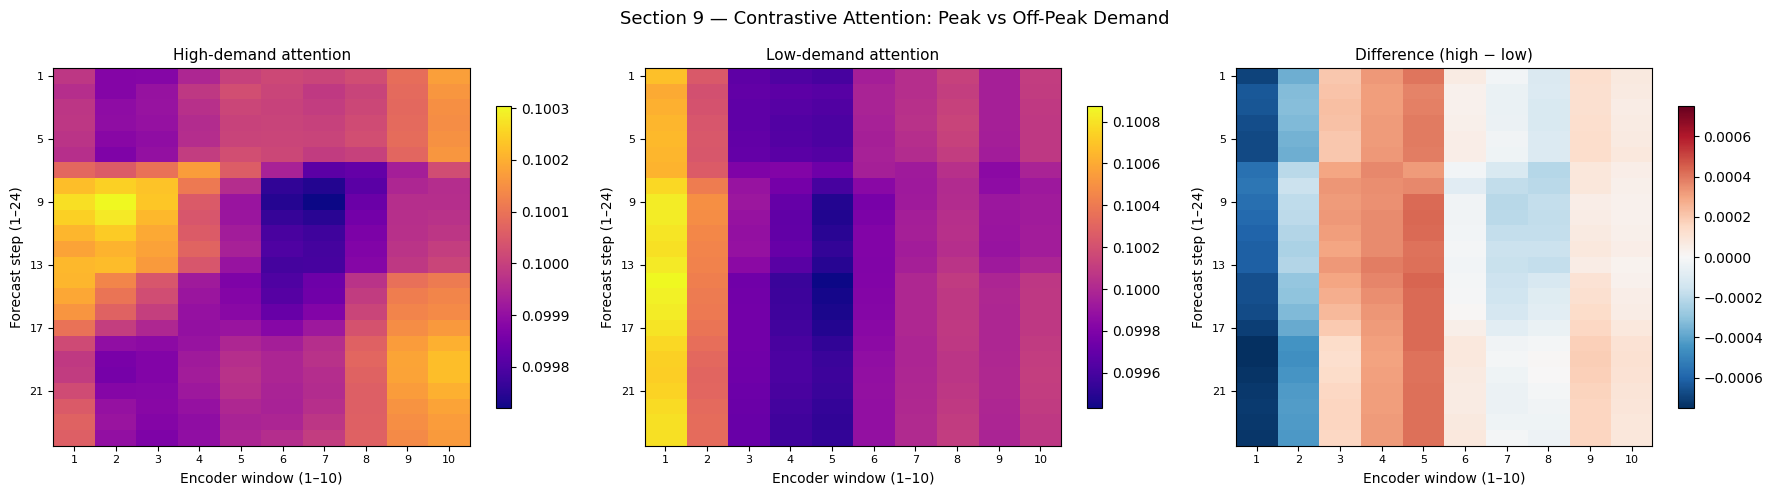

In [16]:
# Identify peak (top 25%) and off-peak (bottom 25%) samples by mean demand
mean_demand = y_target[:EXT_BATCH, :, 0].mean(axis=1)    # (EXT_BATCH,)
threshold_hi = np.percentile(mean_demand, 75)
threshold_lo = np.percentile(mean_demand, 25)

hi_idx = np.where(mean_demand >= threshold_hi)[0]
lo_idx = np.where(mean_demand <= threshold_lo)[0]
print(f'High-demand samples : {len(hi_idx)}  (mean demand >= {threshold_hi:.2f})')
print(f'Low-demand  samples : {len(lo_idx)}  (mean demand <= {threshold_lo:.2f})')

# Re-extract attention for each group
res_hi = extractor.extract([ext_s[hi_idx], ext_d[hi_idx], ext_f[hi_idx]])
res_lo = extractor.extract([ext_s[lo_idx], ext_d[lo_idx], ext_f[lo_idx]])

# Use cross-attention for comparison
attn_list_hi = list(res_hi['attention'].values())
attn_list_lo = list(res_lo['attention'].values())
cross_hi = attn_list_hi[cross_idx].mean(axis=(0, 1))   # (H, K_enc) mean over batch+heads
cross_lo = attn_list_lo[cross_idx].mean(axis=(0, 1))

diff_map = cross_hi - cross_lo                          # positive = hi attends MORE

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ['High-demand attention', 'Low-demand attention', 'Difference (high − low)']
maps   = [cross_hi, cross_lo, diff_map]
cmaps  = ['plasma', 'plasma', 'RdBu_r']
for ax, data, title, cmap in zip(axes, maps, titles, cmaps):
    vmax = max(abs(data.max()), abs(data.min()))
    vkwargs = dict(vmin=-vmax, vmax=vmax) if 'Diff' in title else {}
    im = ax.imshow(data, aspect='auto', cmap=cmap, **vkwargs)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f'Encoder window (1–{K_ENC})')
    ax.set_ylabel('Forecast step (1–24)')
    ax.set_xticks(range(K_ENC))
    ax.set_xticklabels([str(k+1) for k in range(K_ENC)], fontsize=8)
    ax.set_yticks(range(0, HORIZON, 4))
    ax.set_yticklabels([str(s+1) for s in range(0, HORIZON, 4)], fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Section 9 — Contrastive Attention: Peak vs Off-Peak Demand',
             fontsize=13)
plt.tight_layout(); plt.show()


### Interpreting Contrastive Attention

**Difference map** (rightmost): *red* regions are encoder windows that the model
pays *more* attention to for high-demand predictions; *blue* regions are attended
to more for low-demand predictions.

If high-demand samples concentrate attention on recent encoder windows (right side,
red), it confirms the model has learned that peak demand follows business-hour
occupancy signals that are *predictable from the immediate past*.

If the difference is small or random, it suggests the model uses a similar
"attention recipe" regardless of demand level — which could indicate that the
learned representations already absorbed the relevant context into the encoder
output, making the downstream attention patterns similar.

---

## 10 — Integrated Gradients

Standard gradient saliency measures the *gradient at the actual input*.  For
non-linear models this can be misleading if the model is in a saturation region.

**Integrated gradients** (Sundararajan et al., 2017) instead averages gradients
along a straight-line path from a **baseline** (zeros) to the actual input:

```
IG(x) = (x − x_baseline) × ∫₀¹ ∂f(x_baseline + α(x−x_baseline))/∂x  dα
```

This satisfies the *completeness axiom*: the sum of attributions equals the
model's output change from baseline to input.

In [17]:
N_STEPS = 20   # integration steps (higher = more accurate but slower)

xs_base = tf.zeros_like(ext_s)
xd_base = tf.zeros_like(ext_d)
xf_base = tf.zeros_like(ext_f)

ig_dynamic = np.zeros_like(ext_d)   # (EXT_BATCH, LOOKBACK, N_DYNAMIC)
ig_future  = np.zeros_like(ext_f)   # (EXT_BATCH, HORIZON,  N_FUTURE)
ig_static  = np.zeros_like(ext_s)   # (EXT_BATCH, N_STATIC)

for step in range(N_STEPS + 1):
    alpha = step / N_STEPS
    xd_interp = tf.Variable(xd_base + alpha * (ext_d - xd_base), dtype=tf.float32)
    xf_interp = tf.Variable(xf_base + alpha * (ext_f - xf_base), dtype=tf.float32)
    xs_interp = tf.Variable(xs_base + alpha * (ext_s - xs_base), dtype=tf.float32)

    with tf.GradientTape() as tape:
        pred = model([xs_interp, xd_interp, xf_interp], training=False)
        scalar = tf.reduce_mean(pred)

    gs_i, gd_i, gf_i = tape.gradient(scalar, [xs_interp, xd_interp, xf_interp])
    ig_dynamic += gd_i.numpy() / N_STEPS
    ig_future  += gf_i.numpy() / N_STEPS
    ig_static  += gs_i.numpy() / N_STEPS

# Element-wise multiply by (input - baseline)
ig_dynamic *= (ext_d - xd_base.numpy())
ig_future  *= (ext_f - xf_base.numpy())
ig_static  *= (ext_s - xs_base.numpy())

# Mean absolute attribution over batch
ig_d_feat = np.abs(ig_dynamic).mean(axis=(0, 1))   # (N_DYNAMIC,)
ig_f_feat = np.abs(ig_future ).mean(axis=(0, 1))   # (N_FUTURE,)
ig_s_feat = np.abs(ig_static ).mean(axis=0)        # (N_STATIC,)

print('Integrated gradients computed.')
print()
print('Dynamic IG (sorted):')
for name, val in sorted(zip(DYNAMIC_NAMES, ig_d_feat), key=lambda x: -x[1]):
    print(f'  {name:20s} : {val:.6f}  [{IMPORTANCE[name]}]')


Integrated gradients computed.

Dynamic IG (sorted):
  wind_speed           : 0.000011  [LOW]
  humidity             : 0.000006  [MOD]
  price_signal         : 0.000001  [LOW]
  temperature          : 0.000000  [HIGH]
  cloud_cover          : 0.000000  [LOW]
  occupancy            : 0.000000  [HIGH]


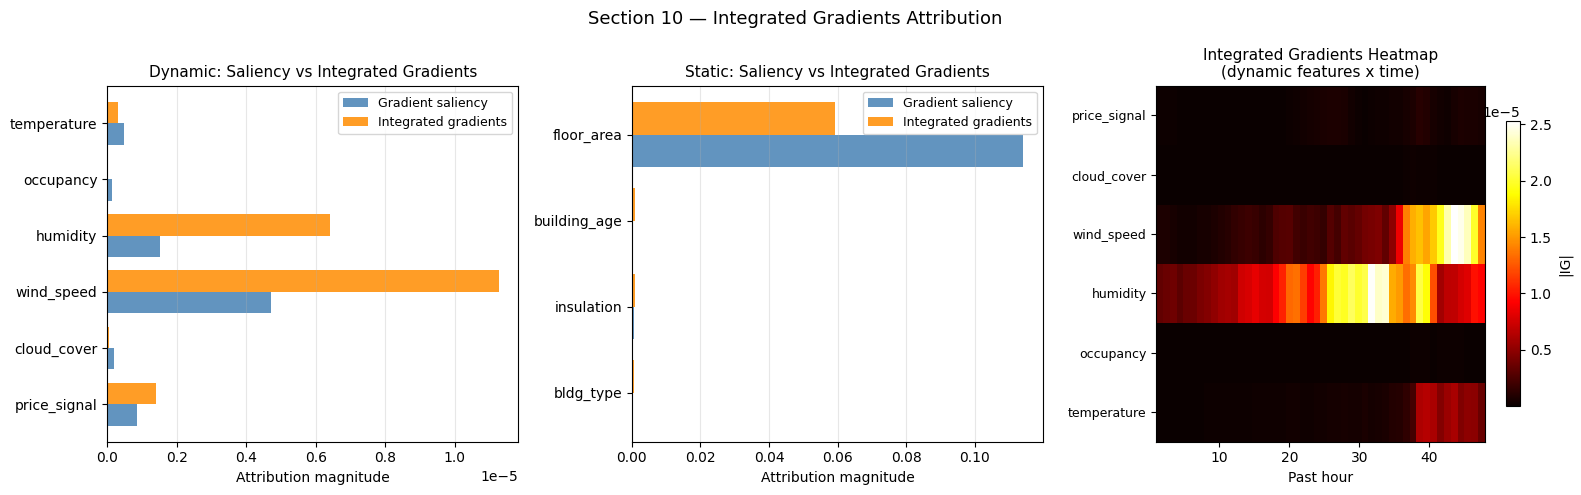

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Compare gradient saliency vs integrated gradients for dynamic features
ax = axes[0]
x_pos = np.arange(N_DYNAMIC)
width = 0.38
bars1 = ax.barh(x_pos + width/2, sal_dynamic.mean(axis=0),  width,
                color='steelblue', label='Gradient saliency', alpha=0.85)
bars2 = ax.barh(x_pos - width/2, ig_d_feat, width,
                color='darkorange', label='Integrated gradients', alpha=0.85)
ax.set_yticks(x_pos)
ax.set_yticklabels(DYNAMIC_NAMES)
ax.set_xlabel('Attribution magnitude')
ax.set_title('Dynamic: Saliency vs Integrated Gradients', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='x'); ax.invert_yaxis()

# Static comparison
ax = axes[1]
x_pos_s = np.arange(N_STATIC)
ax.barh(x_pos_s + width/2, sal_static,  width,
        color='steelblue', label='Gradient saliency', alpha=0.85)
ax.barh(x_pos_s - width/2, ig_s_feat, width,
        color='darkorange', label='Integrated gradients', alpha=0.85)
ax.set_yticks(x_pos_s)
ax.set_yticklabels(STATIC_NAMES)
ax.set_xlabel('Attribution magnitude')
ax.set_title('Static: Saliency vs Integrated Gradients', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='x'); ax.invert_yaxis()

# Integrated gradient heatmap for dynamic (averaged over batch)
ax = axes[2]
ig_d_heatmap = np.abs(ig_dynamic).mean(axis=0).T   # (N_DYNAMIC, LOOKBACK)
im = ax.imshow(ig_d_heatmap, aspect='auto', cmap='hot',
               extent=[1, LOOKBACK, -0.5, N_DYNAMIC - 0.5])
ax.set_yticks(range(N_DYNAMIC))
ax.set_yticklabels(DYNAMIC_NAMES, fontsize=9)
ax.set_xlabel('Past hour'); ax.set_title('Integrated Gradients Heatmap\n(dynamic features x time)', fontsize=11)
plt.colorbar(im, ax=ax, label='|IG|', shrink=0.8)

plt.suptitle('Section 10 — Integrated Gradients Attribution', fontsize=13)
plt.tight_layout(); plt.show()


### Interpreting Integrated Gradients

**Agreement with gradient saliency** (left two panels): if the orange and blue
bars are ordered identically (same feature ranking), both methods agree and the
model is not in a saturation regime.  If they *disagree*, integrated gradients
is more reliable because it accounts for the model's full non-linearity along
the path from zero to the input.

**IG heatmap** (right): the temporal pattern should mirror the gradient saliency
heatmap (Section 7B) but may differ in magnitude near input saturation zones.
Recent time steps should remain brighter, confirming that *recent context* carries
the most attribution mass.

**Key difference from saliency**: integrated gradients attribute the full output
*change* from baseline; gradient saliency only reflects *local* sensitivity.  For
features near zero (e.g. after normalisation) they often agree; for large-valued
features they can diverge.

---

## Summary

| Section | Technique | Key question answered |
|---------|-----------|----------------------|
| 3 | VSN Feature Importance | Which features does the model route most signal through? |
| 4 | Cross-Attention Heatmap | Which encoder windows does each decoder step query? |
| 5 | Hierarchical Self-Attention | How do forecast steps relate to one another? |
| 6 | Multi-Head Diversity | Are the 4 heads specialising or redundant? |
| 7 | Gradient Saliency | Which inputs/timesteps drive the output locally? |
| 8 | Horizon-Dependent Attention | Does focus shift as we forecast further ahead? |
| 9 | Contrastive Analysis | Do high vs low demand samples use different context? |
| 10 | Integrated Gradients | Full attribution accounting for non-linearity? |

### Key Takeaways

- **VSN and gradient attribution should agree**: if both identify `temperature`,
  `occupancy`, and `floor_area` as most important and the formula confirms this,
  the model has learned the right signals.
- **Cross-attention recency gradient** (later encoder windows attract more weight
  for early forecast steps) is the expected and physically interpretable pattern.
- **Entropy increases with horizon**: a healthy model is *more uncertain* about
  distant future states, which should manifest as higher cross-attention entropy
  at long horizons.
- **Multi-head diversity**: low off-diagonal similarity in the head similarity
  matrix indicates the model is using its capacity efficiently.
- **Integrated gradients vs gradient saliency**: agreement between both methods
  is a sign the model is not saturating — the input features operate in a
  well-conditioned region of the activation landscape.

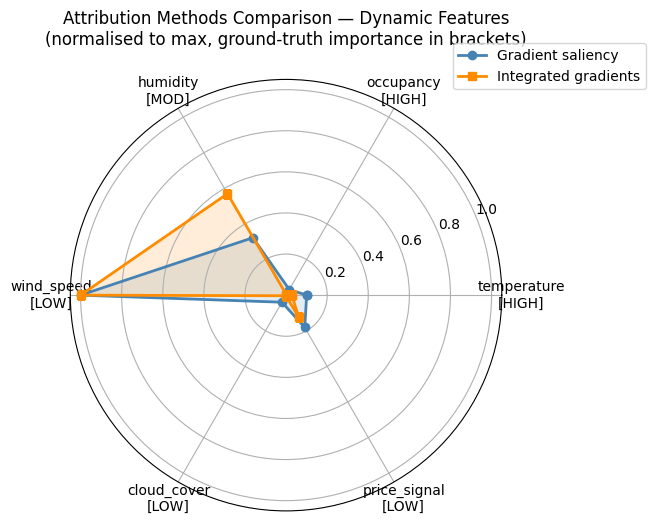


GREEN bracket = HIGH importance  |  ORANGE = MOD  |  GREY = LOW
Both methods should place the largest polygon vertex on temperature and occupancy.


In [19]:
# Summary radar chart: compare attribution methods for dynamic features
from matplotlib.patches import FancyArrowPatch

angles  = np.linspace(0, 2 * np.pi, N_DYNAMIC, endpoint=False).tolist()
angles += angles[:1]

sal_vals = (sal_dynamic.mean(axis=0) / sal_dynamic.mean(axis=0).max()).tolist()
ig_vals  = (ig_d_feat / ig_d_feat.max()).tolist()
sal_vals += sal_vals[:1]
ig_vals  += ig_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, sal_vals,  'o-', lw=2, color='steelblue',  label='Gradient saliency')
ax.fill(angles, sal_vals,  alpha=0.15, color='steelblue')
ax.plot(angles, ig_vals,   's-', lw=2, color='darkorange', label='Integrated gradients')
ax.fill(angles, ig_vals,   alpha=0.15, color='darkorange')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [f'{n}\n[{IMPORTANCE[n]}]' for n in DYNAMIC_NAMES],
    fontsize=10
)
ax.set_title('Attribution Methods Comparison — Dynamic Features\n'
             '(normalised to max, ground-truth importance in brackets)',
             fontsize=12, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout(); plt.show()
print()
print('GREEN bracket = HIGH importance  |  ORANGE = MOD  |  GREY = LOW')
print('Both methods should place the largest polygon vertex on temperature and occupancy.')
